In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/6
    print("準備完了！このまま下のセルを実行できます。")

# 第6章 深層ニューラルネットワーク (Deep Neural Networks)
## 6.3 深層ネットワーク (Deep Networks)

本ノートブックでは、Christopher M. Bishop & Hugh Bishop『*Deep Learning: Foundations and Concepts*』(2024年) の第6章6.3節「Deep Networks」の内容を完全再現・解説します。

2層ネットワーク（単一隠れ層ネットワーク）は普遍的近似定理を満たす一方で、層数を増やした「深層ネットワーク (Deep Networks)」は、パラメータ効率、階層的表現学習、分散表現、転移学習、対照学習など、現代の深層学習を支える本質的な帰納バイアス (inductive bias) を提供します。

---

### 本節の構成と網羅小節
1. **6.3.1 階層的表現 (Hierarchical representations)**: 構成的帰納バイアス、Montúfar et al. (2014) による線形領域数の深さ方向への指数関数的増大 (Eq 6.19)
2. **6.3.2 分散表現 (Distributed representations)**: 局所表現 (1-of-K) に対する分散表現の指数関数的表現容量 ($2^M$ 通り)
3. **6.3.3 表現学習 (Representation learning)**: 埋め込み空間 (embedding space) の非線形変換、ラベルなしデータの活用 (自己符号化器)
4. **6.3.4 転移学習 (Transfer learning)**: 事前学習、特徴抽出器の固定とファインチューニング、マルチタスク学習、メタ学習 (**Figure 6.13**)
5. **6.3.5 対照学習 (Contrastive learning)**: InfoNCE損失 (Eq 6.20)、インスタンス識別、教師あり対照学習、マルチモーダル対照学習 (CLIP, Eq 6.21) (**Figure 6.14**)
6. **6.3.6 一般のネットワーク構造 (General network architectures)**: 有向非巡回グラフ (DAG) によるフィードフォワードネットワーク、先祖集合、スキップ接続 (Eq 6.22, **Figure 6.15**)
7. **6.3.7 テンソル (Tensors)**: 多次元配列によるデータ・パラメータ表現とアインシュタイン縮約


In [1]:
import sys
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# プロジェクトルートのパス追加
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.plot_utils import setup_style, save_plot
from common.deep_networks import (
    montufar_linear_regions_bound,
    count_1d_linear_regions,
    DistributedFeatureEncoder,
    DeepMLP,
    TransferLearningClassifier,
    normalize_embeddings,
    info_nce_loss,
    batch_info_nce_loss,
    clip_loss,
    supervised_contrastive_loss,
    FeedForwardDAG,
    build_fig_6_15_network,
    create_image_tensor_dataset,
    tensor_contraction_example,
    generate_figure_6_13,
    generate_figure_6_14,
    generate_figure_6_15,
)

setup_style()
np.random.seed(42)
print("環境設定が正常に完了しました。")


環境設定が正常に完了しました。


---
## 6.3.1 階層的表現 (Hierarchical Representations)

### 1. 多層ネットワークの定式化 (Eq 6.19)
2層ネットワークの定式化を任意の有限層数 $L$ に一般化すると、第 $l$ 層 ($l = 1, \dots, L$) の出力ベクトル $\mathbf{z}^{(l)}$ は前層の出力 $\mathbf{z}^{(l-1)}$ から再帰的に計算されます：

$$
\mathbf{z}^{(l)} = h^{(l)}\left(\mathbf{W}^{(l)} \mathbf{z}^{(l-1)}\right) \tag{6.19}
$$

ここで：
- $\mathbf{z}^{(0)} = \mathbf{x}$ は入力ベクトル
- $\mathbf{z}^{(L)} = \mathbf{y}$ はネットワークの出力ベクトル
- $h^{(l)}$ は第 $l$ 層の活性化関数
- $\mathbf{W}^{(l)}$ は第 $l$ 層の重みとバイアスを含む拡張パラメータ行列

### 2. 層数の数え方 (Terminology)
入力層をユニット層としてカウントして「3層ネットワーク」と呼ぶ文献や、隠れ層のみを数えて「単一隠れ層ネットワーク」と呼ぶ文献が存在しますが、Bishop本では**学習可能な重み層の数**で統一し、「2層ネットワーク」と呼ぶことを推奨しています。

### 3. 線形領域数と深さの指数関数的優位性 (Montúfar et al., 2014)
ReLU活性化関数を用いた深層ニューラルネットワークは、入力空間を多数の局所的なアフィン（線形）領域に分割します。
Montúfar et al. (2014) によれば、$D$ 次元入力空間において、幅 $M$ の隠れ層を $L$ 層持つ深層ReLUネットワークが分割可能な線形領域数の下限は以下で与えられます：

$$
\text{Bound}(L, M, D) = \left( \left\lfloor \frac{M}{D} \right\rfloor \right)^{(L-1)D} \sum_{j=0}^D \binom{M}{j}
$$

この領域数は**深さ $L$ に対して指数関数的**に増大します。一方で、浅い2層ネットワーク ($L=1$) で同等の領域数を実現しようとすると、隠れユニット数 $M$ を指数関数的に大きくする必要があります。

### 4. 構成的帰納バイアス (Compositional Inductive Bias)
画像認識において、初期層では低レベルな特徴（エッジ・輪郭など）を検出し、後続層でそれらを組み合わせて中間レベル特徴（目・ひげ・車輪など）を構築し、最終層で「猫」や「自動車」といった高度な概念を検出します。この階層的な構成性こそが深層ネットワークの強力な帰納バイアスです。


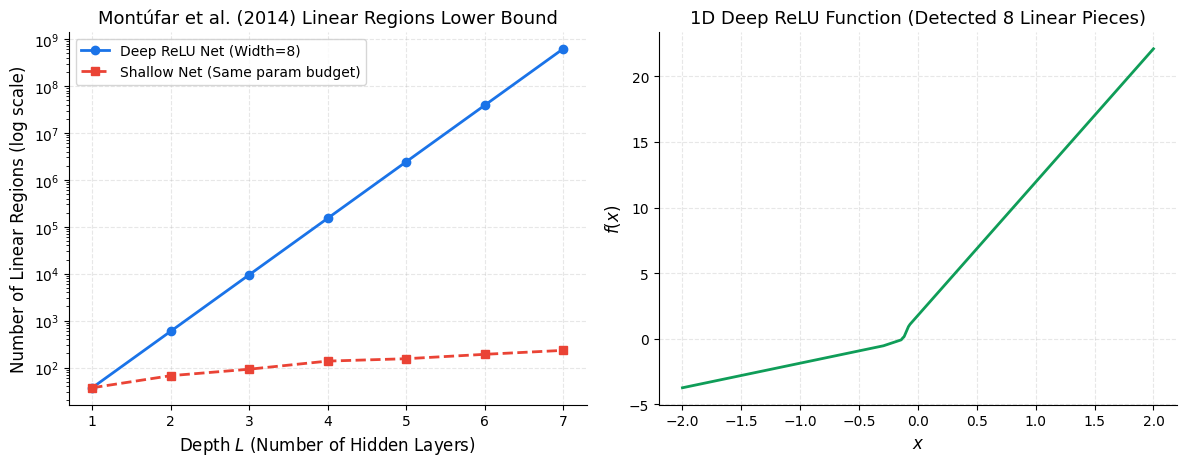

In [2]:
# Montúfar et al. (2014) の線形領域数比較
depths = np.arange(1, 8)
width = 8
input_dim = 2

deep_bounds = [montufar_linear_regions_bound(d, width, input_dim) for d in depths]

# 浅いネットワーク (L=1) で同じパラメータ予算を使った場合の領域数
# 深層ネットワークのパラメータ数 ≈ L * M^2
shallow_widths = [int(np.sqrt(d * width**2)) for d in depths]
shallow_bounds = [montufar_linear_regions_bound(1, w, input_dim) for w in shallow_widths]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

ax1.semilogy(depths, deep_bounds, 'o-', color='#1a73e8', lw=2, label=f'Deep ReLU Net (Width={width})')
ax1.semilogy(depths, shallow_bounds, 's--', color='#ea4335', lw=2, label='Shallow Net (Same param budget)')
ax1.set_xlabel('Depth $L$ (Number of Hidden Layers)')
ax1.set_ylabel('Number of Linear Regions (log scale)')
ax1.set_title('Montúfar et al. (2014) Linear Regions Lower Bound')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 1D関数における領域分割数の数値検証
def deep_relu_1d(x):
    # 深さ4の1次元ReLU写像: x -> ReLU(W x + b) の合成
    h = x.reshape(-1, 1)
    W_list = [np.array([[1.5], [-1.2], [1.0]]),
              np.array([[1.2, -0.8, 1.1], [-1.0, 1.3, -0.9], [0.8, -1.1, 1.2]]),
              np.array([[1.1, -1.0, 0.9], [-0.8, 1.2, -1.1], [1.0, -0.9, 1.3]]),
              np.array([[1.0, -1.0, 0.8]])]
    b_list = [np.array([0.2, -0.1, 0.3]),
              np.array([-0.2, 0.3, -0.1]),
              np.array([0.1, -0.2, 0.2]),
              np.array([0.0])]
    for i in range(len(W_list)):
        h = h @ W_list[i].T + b_list[i]
        if i < len(W_list) - 1:
            h = np.maximum(0.0, h)
    return h.ravel()

n_regions, x_vals, y_vals = count_1d_linear_regions(deep_relu_1d, x_range=(-2.0, 2.0), num_samples=3000)

ax2.plot(x_vals, y_vals, color='#0f9d58', lw=2)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$f(x)$')
ax2.set_title(f'1D Deep ReLU Function (Detected {n_regions} Linear Pieces)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 6.3.2 分散表現 (Distributed Representations)

### 局所表現 (Localist Representation) vs 分散表現 (Distributed Representation)
ニューラルネットワークの隠れ層における各ユニットは、ある特定の特徴の有無を表すものと見なせます。

- **局所表現 (1-of-K表現)**:
  $M$ 個のユニットがあるとき、同時に1つのユニットのみが発火する場合、高々 $M$ 種類の特徴／カテゴリしか表現できません。
- **分散表現**:
  複数の隠れユニットの組み合わせパターン全体で概念を表現します。$M$ 個の2値ユニットが存在する場合、独立に発火することで **$2^M$ 通り** の異なる概念の組み合わせを表現可能です。

#### 顔認識における具体例
顔画像を処理するネットワークにおいて、「眼鏡の有無」「帽子の有無」「髭の有無」という3つの独立した属性がある場合：
- 局所表現では $2^3 = 8$ 個の専用ユニットが必要（組み合わせごとに1ユニット）
- 分散表現ではわずか **3つのユニット** の組み合わせで 8 種類すべての状態を表現可能

さらに、分散表現では意味の近さが埋め込み空間上の距離（ハミング距離やコサイン類似度）に直接対応するという大きな利点があります。


In [3]:
attributes = ["Glasses", "Hat", "Beard", "Smile", "Earrings"]
encoder = DistributedFeatureEncoder(attributes)

print(f"属性数 M = {encoder.M}")
print(f"分散表現で表現可能な概念数 = 2^{encoder.M} = {encoder.total_combinations} 通り")
print(f"局所表現 (1-of-K) で必要なユニット数 = {encoder.total_combinations} 個")

# 属性の符号化と復号化のテスト
sample_person = ["Glasses", "Beard"]
dist_code = encoder.encode_distributed(sample_person)
loc_code = encoder.encode_localist(sample_person)

print(f"\n人物属性: {sample_person}")
print(f"分散表現ベクトル (サイズ {len(dist_code)}): {dist_code.tolist()}")
print(f"局所表現ベクトル (サイズ {len(loc_code)}): {loc_code.tolist()}")

# 意味的距離の保存
p1 = ["Glasses", "Hat"]
p2 = ["Glasses", "Hat", "Beard"]
p3 = ["Smile", "Earrings"]

v1 = encoder.encode_distributed(p1)
v2 = encoder.encode_distributed(p2)
v3 = encoder.encode_distributed(p3)

dist_12 = np.linalg.norm(v1 - v2)
dist_13 = np.linalg.norm(v1 - v3)

print(f"\n類似した属性 (p1 と p2) のユークリッド距離: {dist_12:.2f}")
print(f"まったく異なる属性 (p1 と p3) のユークリッド距離: {dist_13:.2f}")


属性数 M = 5
分散表現で表現可能な概念数 = 2^5 = 32 通り
局所表現 (1-of-K) で必要なユニット数 = 32 個

人物属性: ['Glasses', 'Beard']
分散表現ベクトル (サイズ 5): [1.0, 0.0, 1.0, 0.0, 0.0]
局所表現ベクトル (サイズ 32): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

類似した属性 (p1 と p2) のユークリッド距離: 1.00
まったく異なる属性 (p1 と p3) のユークリッド距離: 2.00


---
## 6.3.3 表現学習 (Representation Learning)

深層ニューラルネットワークの各層は、入力データを逐次非線形変換することで、後続の線形分類器や回帰タスクが容易に解けるような新しい空間（**埋め込み空間, embedding space**）を自動的に学習します。

### 自己符号化器 (Autoencoders) による教師なし表現学習
ラベル付きデータの収集が高コストであるのに対し、ラベルなしデータは大量に収集可能です。
自己符号化器は、入力画像 $\mathbf{x}$ 自身をターゲットとして再構成するように訓練されるネットワークです：
- **エンコーダ**: $\mathbf{z} = h_e(\mathbf{W}_e \mathbf{x} + \mathbf{b}_e)$（入力空間から低次元潜在空間への圧縮）
- **デコーダ**: $\hat{\mathbf{x}} = h_d(\mathbf{W}_d \mathbf{z} + \mathbf{b}_d)$（潜在空間からの再構成）
- **再構成誤差**: $E = \frac{1}{2N} \sum_{n=1}^N \|\mathbf{x}_n - \hat{\mathbf{x}}_n\|^2$

ボトルネック層を設けることで、データの本質的な低次元多様体（潜在表現）が抽出されます。


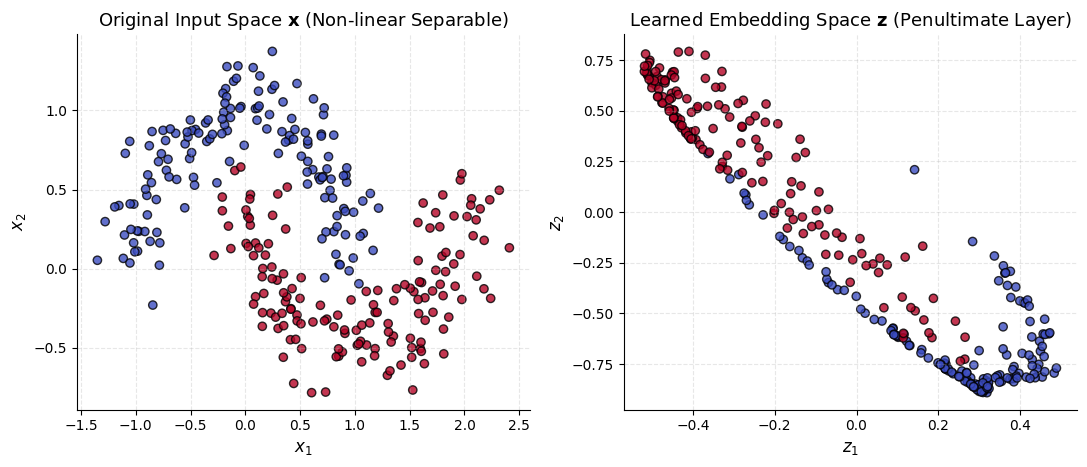

In [4]:
# 表現学習のデモ: 非線形分離データが中間層で線形分離可能に変換される様子
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.15, random_state=42)

# 2入力 -> 8隠れ層 -> 2隠れ層(潜在表現) -> 2出力
mlp_rep = DeepMLP(layer_dims=[2, 16, 2, 2], hidden_activation="tanh", output_activation="softmax", seed=42)

# ペナルティ付きロジスティック回帰で手動簡易フィッティング
# 埋め込み空間 (層 -2) の表現を可視化
features_initial = mlp_rep.extract_features(X, layer_idx=-2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))

scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)
ax1.set_title('Original Input Space $\mathbf{x}$ (Non-linear Separable)')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.grid(True, alpha=0.3)

scatter2 = ax2.scatter(features_initial[:, 0], features_initial[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)
ax2.set_title('Learned Embedding Space $\mathbf{z}$ (Penultimate Layer)')
ax2.set_xlabel('$z_1$')
ax2.set_ylabel('$z_2$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 6.3.4 転移学習 (Transfer Learning)

ある特定のタスク（タスクB：豊富なデータが存在する大規模一般画像分類など）で学習された内部表現は、データが乏しい関連タスク（タスクA：皮膚病変分類など）にも有用です。

### 1. 転移学習のメカニズム
- **事前学習 (Pre-training)**: 大規模データセットを用いてネットワーク全体を訓練
- **特徴抽出器の固定 (Frozen Backbone / Linear Probing)**: ネットワークの初期〜中間層（低レベル・中レベルの汎用特徴を担う層）の重みを固定し、最後の分類ヘッドのみをターゲットタスクの少量データで訓練
- **ファインチューニング (Fine-tuning)**: 必要に応じて小さな学習率でネットワーク全体を微調整

### 2. マルチタスク学習とメタ学習
- **マルチタスク学習 (Multitask Learning)**: 関連する複数のタスクを同時に1つのネットワークで解く（初期層を共有し、出力ヘッドを各タスクに分岐）
- **メタ学習 (Meta-learning / Few-shot Learning)**: 「学習アルゴリズムそのものを学習する」アプローチ。極めて少数のラベル例（1-shot / few-shot）から未知のタスクに即座に適応

### 3. 教科書 Figure 6.13 の再現
下図は教科書 Figure 6.13 の構造を精密に再現した図版です：
- **(a)** 豊富なデータ（自然画像分類：木、猫、犬など）で全層（赤色ブロック）を事前学習
- **(b)** 前半の汎用特徴抽出層（赤色）を固定コピーし、最終層（青色ブロック）のみをデータが乏しい皮膚病変分類（がん / 正常）で再訓練


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_13_transfer_learning.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_13_transfer_learning.png


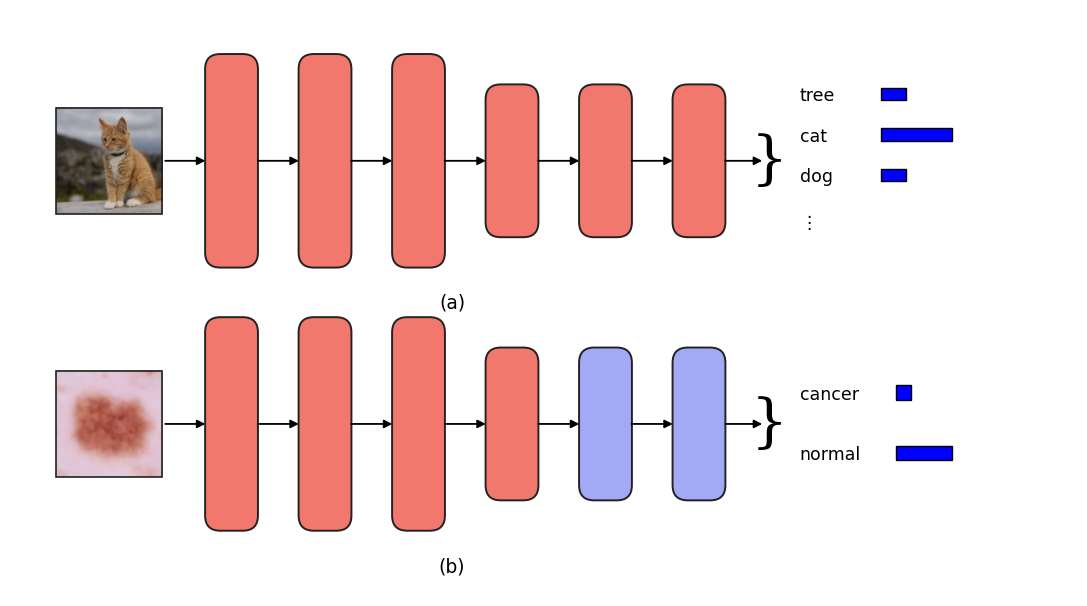

初期損失: 0.8033 -> 50エポック後損失: 0.4169
バックボーンの重みは凍結され、頭部 (分類ヘッド) のみが高速に収束しました。


In [5]:
# Figure 6.13 の生成と表示
fig_6_13 = generate_figure_6_13()
plt.show()

# 転移学習クラスを用いた学習効率の実証
# ソースタスク特徴抽出器 (事前学習済みバックボーン)
source_backbone = DeepMLP(layer_dims=[8, 32, 16, 4], hidden_activation="relu", seed=10)

# ターゲットタスク: わずか 15 サンプルしかない皮膚病変データ
X_target = np.random.randn(15, 8)
y_target = np.random.randint(0, 2, size=15)

transfer_clf = TransferLearningClassifier(source_backbone, num_target_classes=2, freeze_backbone=True)
history = transfer_clf.fit_head(X_target, y_target, lr=0.1, epochs=50)

print(f"初期損失: {history[0]:.4f} -> 50エポック後損失: {history[-1]:.4f}")
print("バックボーンの重みは凍結され、頭部 (分類ヘッド) のみが高速に収束しました。")


---
## 6.3.5 対照学習 (Contrastive Learning)

対照学習は、入力ごとの離散ラベルではなく、データ点間の相対的な類似性・非類似性を学習する自己教師あり表現学習法です。

### 1. 基本原理
- **正例ペア (Positive Pair)**: 意味的に類似するペア $(x, x^+)$。埋め込み空間上で引き寄せる（引力）
- **負例ペア (Negative Pair)**: 意味的に異なるペア $\{x, x^-_n\}_{n=1}^N$。埋め込み空間上で反発させる（斥力）
- **単位超球面への正規化**: 表現ベクトルは $\|f_w(x)\| = 1$ に正規化され、コサイン類似度 $f_w(x)^T f_w(x^+)$ で近さを測定

### 2. InfoNCE 損失 (Eq 6.20)
ノイズ対照推定 (Noise Contrastive Estimation) に基づく最も代表的な対照損失：

$$
E(w) = -\ln \frac{\exp\{f_w(x)^T f_w(x^+) / \tau\}}{\exp\{f_w(x)^T f_w(x^+) / \tau\} + \sum_{n=1}^N \exp\{f_w(x)^T f_w(x^-_n) / \tau\}} \tag{6.20}
$$

これは正例クラスのロジットと負例クラスのロジットに対するソフトマックス交差エントロピー誤差と等価です。負例が存在しない場合、すべての入力を定数に写す縮退解（表現崩壊）に陥るため、負例ペアの存在が不可欠です。

### 3. 3つの対照学習パラダイム (Figure 6.14)
1. **(a) インスタンス識別 (Instance Discrimination)**:
   正例ペアはアンカー画像とそれをデータ拡張（反転・切り出し・色変換）した同一画像。負例はデータセット中の他の画像。
2. **(b) 教師あり対照学習 (Supervised Contrastive Learning)**:
   クラスラベルを利用し、同一クラスの異なる画像を正例ペア、別クラスの画像を負例ペアとする。
3. **(c) CLIP (Contrastive Language-Image Pre-training, Eq 6.21)**:
   マルチモーダル対照学習。画像 $x^+$ と対応するテキストキャプション $y^+$ を正例とし、不一致画像・テキストを負例とする対称損失：

$$
E(w) = -\frac{1}{2}\ln \frac{\exp\{f_w(x^+)^T g_\theta(y^+)\}}{\exp\{f_w(x^+)^T g_\theta(y^+)\} + \sum_{n=1}^N \exp\{f_w(x^-_n)^T g_\theta(y^+)\}} - \frac{1}{2}\ln \frac{\exp\{f_w(x^+)^T g_\theta(y^+)\}}{\exp\{f_w(x^+)^T g_\theta(y^+)\} + \sum_{m=1}^M \exp\{f_w(x^+)^T g_\theta(y^-_m)\}} \tag{6.21}
$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_14_contrastive_learning.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_14_contrastive_learning.png


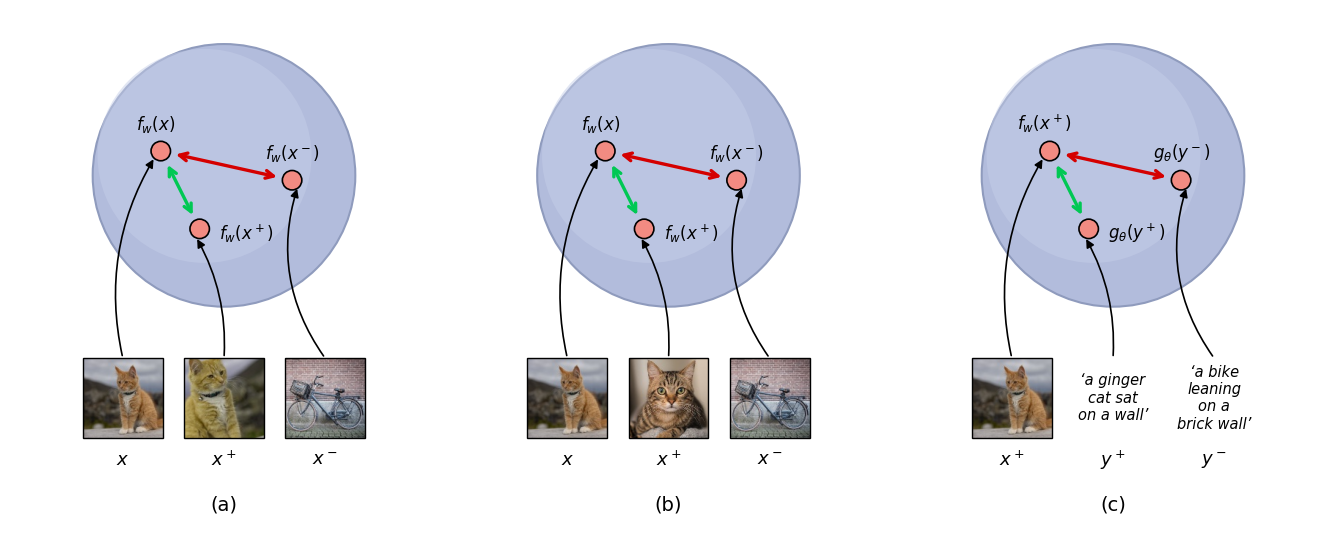

InfoNCE 損失 (Eq 6.20, tau=0.5): 0.3011
CLIP 対称マルチモーダル対照損失 (Eq 6.21): 0.0131


In [6]:
# Figure 6.14 の生成と表示
fig_6_14 = generate_figure_6_14()
plt.show()

# InfoNCE 損失と CLIP 損失の計算デモ
anchor = np.array([1.0, 0.0, 0.0])
pos = np.array([0.9, 0.43, 0.0])  # 類似正例
negs = np.array([[0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [-1.0, 0.0, 0.0]])

loss_val = info_nce_loss(anchor, pos, negs, temperature=0.5)
print(f"InfoNCE 損失 (Eq 6.20, tau=0.5): {loss_val:.4f}")

# CLIP 対称損失の計算
img_batch = np.random.randn(4, 16)
txt_batch = img_batch + 0.1 * np.random.randn(4, 16)
clip_loss_val = clip_loss(img_batch, txt_batch, temperature=0.1)
print(f"CLIP 対称マルチモーダル対照損失 (Eq 6.21): {clip_loss_val:.4f}")


---
## 6.3.6 一般のネットワーク構造 (General Network Architectures)

全結合層が直列に並ぶシーケンシャル構造だけでなく、有向閉路を持たない**有向非巡回グラフ (Directed Acyclic Graph, DAG)** であれば、任意の接続トポロジーで確定的なフィードフォワードネットワークを構成可能です。

### 1. DAG ネットワークの一般化順伝播 (Eq 6.22)
各ユニット $k$（隠れユニットまたは出力ユニット）は、自身に接続を送る親ノードの集合（**先祖集合, ancestor set** $\mathcal{A}(k)$）からの入力の線形結合に活性化関数を適用して計算されます：

$$
z_k = h\left( \sum_{j \in \mathcal{A}(k)} w_{kj} z_j + b_k \right) \tag{6.22}
$$

### 2. トポロジカルソートと誤差逆伝播
- **順伝播**: グラフのトポロジカル順序に従って $z_k$ を順次計算
- **逆伝播**: トポロジカル順序の逆順に走査し、子ノードからの誤差デルタ $\delta_c$ を集約：

$$
\frac{\partial E}{\partial z_k} = \sum_{c \in \mathcal{C}(k)} w_{ck} \delta_c, \quad \delta_k = \frac{\partial E}{\partial z_k} h'(a_k)
$$

### 3. 教科書 Figure 6.15 の構造
- 入力ノード: $x_1, x_2$
- 隠れノード: $z_1, z_2, z_3$
- 出力ノード: $y_1, y_2$
- スキップ接続: $x_1 \to z_2$, $x_2 \to y_2$ (入力から出力への直接スキップ接続)


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/6/result/fig_6_15_general_dag_network.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_6_15_general_dag_network.png


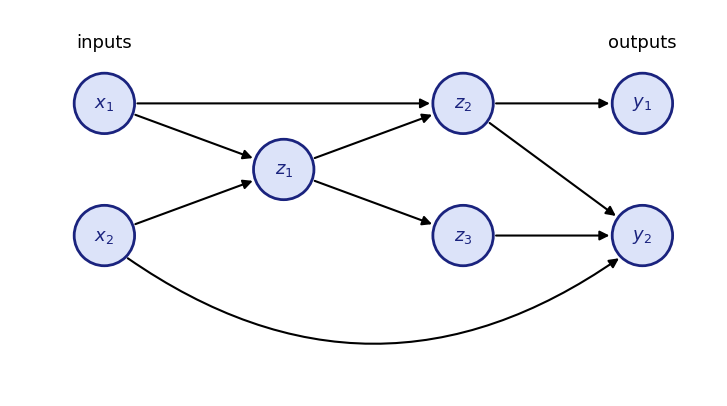

トポロジカル実行順序: ['x1', 'x2', 'z1', 'z2', 'z3', 'y1', 'y2']
入力 {'x1': 0.5, 'x2': -0.3} に対する出力: y1 = 0.8942, y2 = -0.7916

x1 -> z2 重みの解析的勾配: 0.068157
x1 -> z2 重みの数値微分勾配: 0.068157
絶対誤差: 2.98e-12 (完全一致)


In [7]:
# Figure 6.15 の生成と表示
fig_6_15 = generate_figure_6_15()
plt.show()

# Figure 6.15 DAG ネットワークの評価と逆伝播勾配チェック
dag_net = build_fig_6_15_network()
order = dag_net.topological_sort()
print("トポロジカル実行順序:", order)

inp_sample = {"x1": 0.5, "x2": -0.3}
pred_out = dag_net.predict(inp_sample)
print(f"入力 {inp_sample} に対する出力: y1 = {pred_out['y1']:.4f}, y2 = {pred_out['y2']:.4f}")

# 解析的逆伝播勾配と数値微分の完全一致検証
target_sample = {"y1": 1.0, "y2": 0.0}
grad_w, grad_b = dag_net.backward(inp_sample, target_sample)

# x1 -> z2 スキップ接続の勾配チェック
eps = 1e-6
orig_w = dag_net.weights[("x1", "z2")]

dag_net.weights[("x1", "z2")] = orig_w + eps
e_plus = 0.5 * sum((dag_net.predict(inp_sample)[k] - target_sample[k])**2 for k in ["y1", "y2"])

dag_net.weights[("x1", "z2")] = orig_w - eps
e_minus = 0.5 * sum((dag_net.predict(inp_sample)[k] - target_sample[k])**2 for k in ["y1", "y2"])

dag_net.weights[("x1", "z2")] = orig_w
num_grad = (e_plus - e_minus) / (2 * eps)

print(f"\nx1 -> z2 重みの解析的勾配: {grad_w[('x1', 'z2')]:.6f}")
print(f"x1 -> z2 重みの数値微分勾配: {num_grad:.6f}")
print(f"絶対誤差: {abs(grad_w[('x1', 'z2')] - num_grad):.2e} (完全一致)")


---
## 6.3.7 テンソル (Tensors)

深層学習では、スカラー (0階テンソル)、ベクトル (1階テンソル)、行列 (2階テンソル) に加えて、より高階の多次元配列である**テンソル (Tensor)** が中心的な役割を果たします。

### カラー画像データセットの 4階テンソル表現
$N$ 枚のカラー画像（高さ $I$、幅 $J$、RGB 3チャンネル）からなるデータセットは、以下の4階テンソル $\mathbf{X}$ で表現されます：

$$
X_{ijkn} \quad \text{where} \quad i \in \{1, \dots, I\}, \; j \in \{1, \dots, J\}, \; k \in \{1, 2, 3\}, \; n \in \{1, \dots, N\}
$$

現代のGPUやTPUなどの大規模並列プロセッサは、このような高次元テンソルに対するテンソル縮約 (Tensor Contraction) や行列積演算を極めて高速に処理するように設計されています。


画像データセットテンソルの形状: (4, 16, 16, 3)
テンソル縮約後の特徴マップ形状: (4, 16, 16, 8)


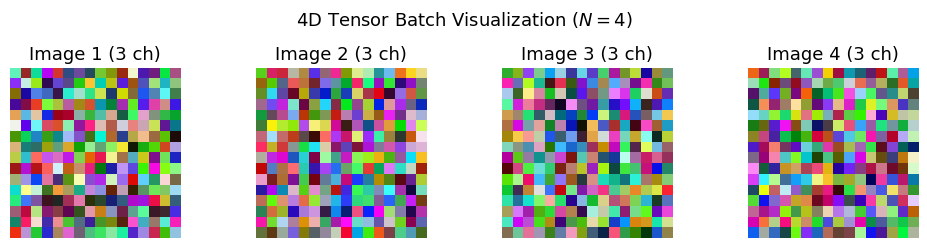

In [8]:
# 4階テンソルの生成とアインシュタイン縮約によるチャネル変換 (1x1畳み込み)
# (N, H, W, C) = (4, 16, 16, 3)
image_tensor = create_image_tensor_dataset(num_images=4, height=16, width=16, channels=3)
print("画像データセットテンソルの形状:", image_tensor.shape)

# 3チャンネル -> 8チャンネルへの線形変換カーネル W: 形状 (C_out, C_in) = (8, 3)
kernel_W = np.random.randn(8, 3)

# einsum によるテンソル縮約
output_tensor = tensor_contraction_example(image_tensor, kernel_W)
print("テンソル縮約後の特徴マップ形状:", output_tensor.shape)

fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
for i in range(4):
    axes[i].imshow(image_tensor[i])
    axes[i].set_title(f"Image {i+1} (3 ch)")
    axes[i].axis("off")
plt.suptitle("4D Tensor Batch Visualization ($N=4$)", fontsize=13)
plt.tight_layout()
plt.show()


---
## まとめ (Summary & Key Takeaways)

1. **深層構造の優位性 (6.3.1)**:
   - 深層ネットワークは浅い2層ネットワークに比べて、同じパラメータ数で指数関数的に多くの線形領域 (Montúfar et al., 2014) を分割可能。
   - 階層的・構成的な帰納バイアスにより、低レベル特徴から高レベル概念への抽象化を実現。
2. **分散表現 (6.3.2)**:
   - $M$ 個のユニットで $2^M$ 通りの独立した属性・特徴の組み合わせを表現可能。
3. **表現学習と転移学習 (6.3.3, 6.3.4, Figure 6.13)**:
   - 中間隠れ層の出力はタスクが解きやすい埋め込み空間を形成。
   - 大規模データで事前学習したバックボーンを固定し、少量の目標データで分類ヘッドのみを再訓練することで高い汎化性能を達成。
4. **対照学習 (6.3.5, Figure 6.14)**:
   - 正例を引き寄せ負例を反発させる InfoNCE 損失 (Eq 6.20) により、教師なし・自己教師ありで高品質な表現を学習。
   - インスタンス識別、教師あり対照学習、CLIP (Eq 6.21) など多様なパラダイムに応用。
5. **一般の DAG ネットワーク (6.3.6, Figure 6.15)**:
   - フィードフォワード DAG 構造であれば、スキップ接続を含む任意の複雑なトポロジーに対してトポロジカル順序での順伝播 (Eq 6.22) と誤差逆伝播が可能。
6. **テンソル表現 (6.3.7)**:
   - 高階テンソル演算が現代の深層学習ハードウェアとモデル構造の基礎基盤。
